 All libraries imported successfully!
 LOADING TELCO CHURN DATASET

 Dataset loaded successfully!
 Shape: (7043, 21)

 First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4     

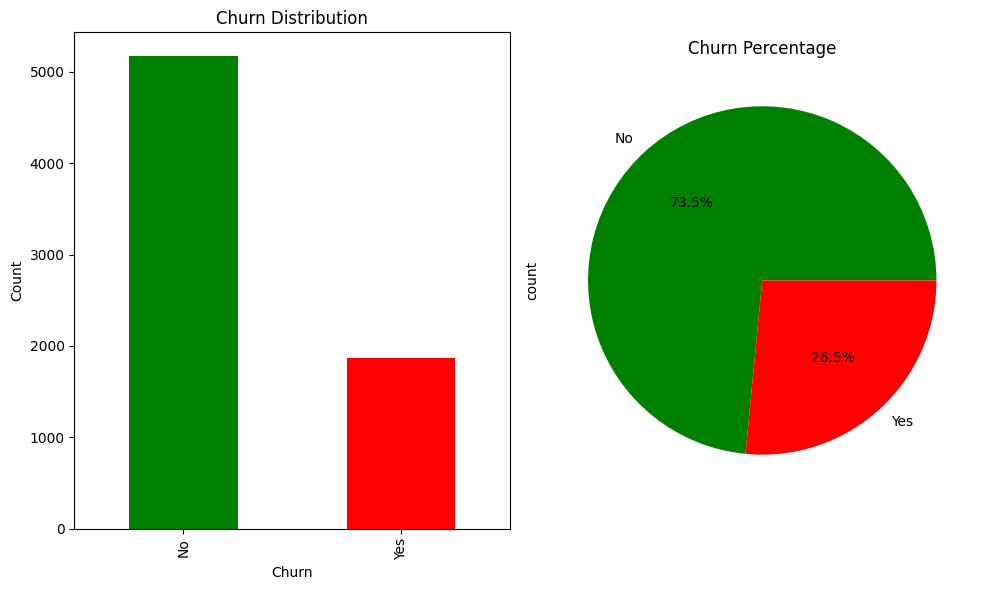


 EDA completed successfully!

 DATA PREPROCESSING
 Removed customerID column. New shape: (7043, 20)

Missing values in TotalCharges: 11

 Features shape: (7043, 19)
 Target shape: (7043,)
 Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

 Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
 Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total categorical features: 16

 BUILDING PREPROCESSING PIPELINE
 Preprocessing pipeline created successfully!

Pipeline structure:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler

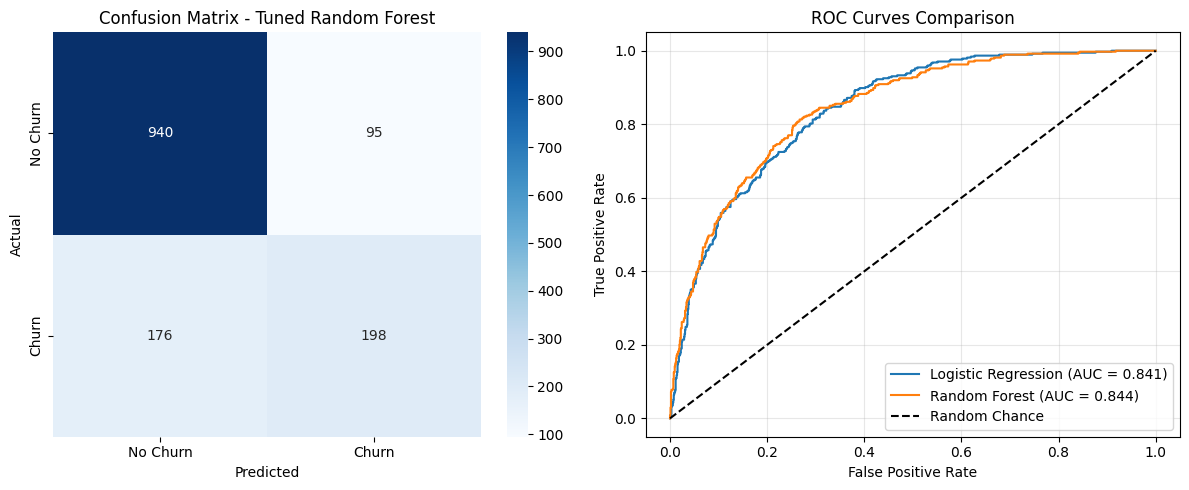

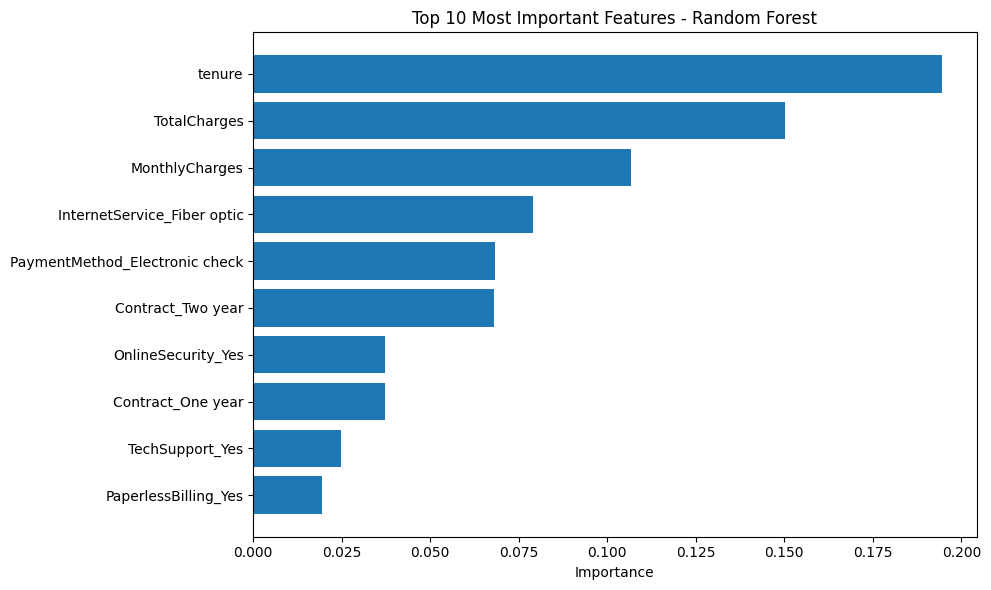


 Visualizations created successfully!

 CROSS-VALIDATION SCORES

 Random Forest Cross-Validation ROC-AUC Scores: [0.85931971 0.85899456 0.84200758 0.83752201 0.8258706 ]
 Mean CV Score: 0.8447 (+/- 0.0258)

 EXPORTING COMPLETE PIPELINE
 Model saved as 'churn_prediction_pipeline.pkl'
 Preprocessor saved as 'preprocessing_pipeline.pkl'
 Model metadata saved as 'model_metadata.json'

 TESTING MODEL REUSABILITY
 Model loaded successfully from 'churn_prediction_pipeline.pkl'

📝 Sample Customer Prediction:
Prediction: Churn
Probability of Churn: 53.37%
Probability of No Churn: 46.63%

✨ TASK 2 COMPLETED SUCCESSFULLY! ✨

 Summary of Accomplishments:
 1. Built complete preprocessing pipeline with scaling and encoding
 2. Trained Logistic Regression and Random Forest models
 3. Performed hyperparameter tuning using GridSearchCV
 4. Exported complete pipeline using joblib
 5. Demonstrated model reusability

 Generated Files:
   - churn_prediction_pipeline.pkl (Complete ML Pipeline)
   - preproc

In [ ]:
# ==========================================
# TASK 2: END-TO-END ML PIPELINE
# Customer Churn Prediction
# ==========================================

# Cell 1: Install and Import Libraries
# Run this cell first
!pip install pandas numpy scikit-learn matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

# Cell 2: Load and Explore Dataset
print("="*60)
print(" LOADING TELCO CHURN DATASET")
print("="*60)

# Load the dataset from URL (Kaggle dataset)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"\n Dataset loaded successfully!")
print(f" Shape: {df.shape}")
print(f"\n First 5 rows:")
print(df.head())

print(f"\n Dataset Info:")
print(df.info())

print(f"\n Basic Statistics:")
print(df.describe())

# Cell 3: Exploratory Data Analysis (EDA)
print("\n" + "="*60)
print(" EXPLORATORY DATA ANALYSIS")
print("="*60)

# Check for missing values
print("\n Missing Values:")
print(df.isnull().sum())

# Check target variable distribution
print("\n Churn Distribution:")
churn_dist = df['Churn'].value_counts()
print(churn_dist)
print(f"\nChurn Rate: {(churn_dist['Yes']/len(df))*100:.2f}%")

# Visualize churn distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Churn Percentage')
plt.tight_layout()
plt.show()

print("\n EDA completed successfully!")

# Cell 4: Data Preprocessing
print("\n" + "="*60)
print(" DATA PREPROCESSING")
print("="*60)

# Create a copy of the dataframe
df_clean = df.copy()

# Remove customerID column (not useful for prediction)
df_clean = df_clean.drop('customerID', axis=1)
print(f" Removed customerID column. New shape: {df_clean.shape}")

# Handle TotalCharges column (convert to numeric, some values are empty strings)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print(f"\nMissing values in TotalCharges: {df_clean['TotalCharges'].isnull().sum()}")

# Fill missing TotalCharges with median
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Separate features and target
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})  # Encode target

print(f"\n Features shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f" Target distribution:\n{y.value_counts()}")

# Identify numeric and categorical columns
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"\n Numeric features: {numeric_features}")
print(f" Categorical features: {categorical_features}")
print(f"Total categorical features: {len(categorical_features)}")

# Cell 5: Build Preprocessing Pipeline
print("\n" + "="*60)
print(" BUILDING PREPROCESSING PIPELINE")
print("="*60)

# Create preprocessing pipelines for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle any remaining missing values
    ('scaler', StandardScaler())  # Scale features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # Fill missing
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))  # One-hot encode
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print(" Preprocessing pipeline created successfully!")
print("\nPipeline structure:")
print(preprocessor)

# Cell 6: Create Complete ML Pipelines
print("\n" + "="*60)
print("🤖 CREATING COMPLETE ML PIPELINES")
print("="*60)

# Create pipeline for Logistic Regression
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Create pipeline for Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print(" Logistic Regression pipeline created!")
print(" Random Forest pipeline created!")
print("\n Pipeline structure:")
print("\nLogistic Regression Pipeline:")
print(log_reg_pipeline)
print("\nRandom Forest Pipeline:")
print(rf_pipeline)

# Cell 7: Split Data
print("\n" + "="*60)
print(" SPLITTING DATA")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Training set size: {X_train.shape}")
print(f" Test set size: {X_test.shape}")
print(f"\n Training set churn distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\n Test set churn distribution:\n{y_test.value_counts(normalize=True)}")

# Cell 8: Train Initial Models (Without Hyperparameter Tuning)
print("\n" + "="*60)
print(" TRAINING INITIAL MODELS")
print("="*60)

# Train Logistic Regression
print("\n Training Logistic Regression...")
log_reg_pipeline.fit(X_train, y_train)
log_reg_pred = log_reg_pipeline.predict(X_test)
log_reg_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("\n Logistic Regression Results:")
print(f"Accuracy: {log_reg_pipeline.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, log_reg_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, log_reg_pred, target_names=['No Churn', 'Churn']))

# Train Random Forest
print("\n Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n Random Forest Results:")
print(f"Accuracy: {rf_pipeline.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

# Cell 9: Hyperparameter Tuning with GridSearchCV
print("\n" + "="*60)
print(" HYPERPARAMETER TUNING WITH GRIDSEARCH CV")
print("="*60)

# Define parameter grids
# For Logistic Regression
log_reg_param_grid = {
    'classifier__C': [0.1, 1.0, 10.0],  # Regularization strength
    'classifier__penalty': ['l2'],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# For Random Forest
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],  # Number of trees
    'classifier__max_depth': [10, 20, None],  # Tree depth
    'classifier__min_samples_split': [2, 5, 10],  # Min samples to split
    'classifier__min_samples_leaf': [1, 2, 4]  # Min samples at leaf
}

print("\n Setting up GridSearch for Logistic Regression...")
log_reg_grid = GridSearchCV(
    log_reg_pipeline,
    log_reg_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC
    n_jobs=-1,  # Use all available cores
    verbose=1
)

print("\n Setting up GridSearch for Random Forest...")
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Cell 10: Perform Grid Search
print("\n" + "="*60)
print(" PERFORMING GRID SEARCH (This may take 3-5 minutes)")
print("="*60)

# Train with GridSearch for Logistic Regression
print("\n Tuning Logistic Regression...")
log_reg_grid.fit(X_train, y_train)
print("\n Best parameters for Logistic Regression:")
print(log_reg_grid.best_params_)
print(f" Best cross-validation score: {log_reg_grid.best_score_:.4f}")

# Train with GridSearch for Random Forest
print("\n Tuning Random Forest...")
rf_grid.fit(X_train, y_train)
print("\n Best parameters for Random Forest:")
print(rf_grid.best_params_)
print(f" Best cross-validation score: {rf_grid.best_score_:.4f}")

# Cell 11: Evaluate Tuned Models
print("\n" + "="*60)
print(" EVALUATING TUNED MODELS")
print("="*60)

# Get best models
best_log_reg = log_reg_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predictions for tuned models
log_reg_tuned_pred = best_log_reg.predict(X_test)
log_reg_tuned_proba = best_log_reg.predict_proba(X_test)[:, 1]

rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_proba = best_rf.predict_proba(X_test)[:, 1]

# Compare results
results = {
    'Model': ['Logistic Regression (Base)', 'Random Forest (Base)',
              'Logistic Regression (Tuned)', 'Random Forest (Tuned)'],
    'Accuracy': [
        log_reg_pipeline.score(X_test, y_test),
        rf_pipeline.score(X_test, y_test),
        best_log_reg.score(X_test, y_test),
        best_rf.score(X_test, y_test)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, log_reg_pred_proba),
        roc_auc_score(y_test, rf_pred_proba),
        roc_auc_score(y_test, log_reg_tuned_proba),
        roc_auc_score(y_test, rf_tuned_proba)
    ]
}

results_df = pd.DataFrame(results)
print("\n Model Performance Comparison:")
print(results_df.to_string(index=False))

# Cell 12: Visualize Results
print("\n" + "="*60)
print(" VISUALIZING RESULTS")
print("="*60)

# Confusion Matrix for Best Model (Tuned Random Forest)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, rf_tuned_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Tuned Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# ROC Curves
plt.subplot(1, 2, 2)

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_tuned_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_tuned_proba)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, log_reg_tuned_proba):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_tuned_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance for Random Forest
# Extract feature names after preprocessing
feature_names = (numeric_features +
                 list(best_rf.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_features)))

importances = best_rf.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names[:len(importances)],
    'importance': importances
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Visualizations created successfully!")

# Cell 13: Cross-Validation Score
print("\n" + "="*60)
print(" CROSS-VALIDATION SCORES")
print("="*60)

# Perform cross-validation on best model
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f"\n Random Forest Cross-Validation ROC-AUC Scores: {cv_scores}")
print(f" Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Cell 14: Export Complete Pipeline
print("\n" + "="*60)
print(" EXPORTING COMPLETE PIPELINE")
print("="*60)

# Save the best model (Random Forest performed better)
model_filename = 'churn_prediction_pipeline.pkl'
joblib.dump(best_rf, model_filename)
print(f" Model saved as '{model_filename}'")

# Also save the preprocessing pipeline separately
preprocessor_filename = 'preprocessing_pipeline.pkl'
joblib.dump(preprocessor, preprocessor_filename)
print(f" Preprocessor saved as '{preprocessor_filename}'")

# Save model metadata
model_info = {
    'model_type': 'RandomForestClassifier',
    'best_params': rf_grid.best_params_,
    'best_score': rf_grid.best_score_,
    'test_accuracy': best_rf.score(X_test, y_test),
    'test_roc_auc': roc_auc_score(y_test, rf_tuned_proba),
    'features': list(X.columns),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features
}

import json
with open('model_metadata.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print(f" Model metadata saved as 'model_metadata.json'")

# Cell 15: Test Loading and Using the Pipeline
print("\n" + "="*60)
print(" TESTING MODEL REUSABILITY")
print("="*60)

# Load the saved pipeline
loaded_pipeline = joblib.load(model_filename)
print(f" Model loaded successfully from '{model_filename}'")

# Test prediction on a single customer
sample_customer = pd.DataFrame({
    'gender': ['Male'],
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'tenure': [24],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['Yes'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['No'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [85.5],
    'TotalCharges': [1500.0]
})

# Make prediction
prediction = loaded_pipeline.predict(sample_customer)
prediction_proba = loaded_pipeline.predict_proba(sample_customer)

print(f"\n📝 Sample Customer Prediction:")
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Probability of Churn: {prediction_proba[0][1]:.2%}")
print(f"Probability of No Churn: {prediction_proba[0][0]:.2%}")

# Cell 16: Final Summary
print("\n" + "="*60)
print("✨ TASK 2 COMPLETED SUCCESSFULLY! ✨")
print("="*60)

print("\n Summary of Accomplishments:")
print(" 1. Built complete preprocessing pipeline with scaling and encoding")
print(" 2. Trained Logistic Regression and Random Forest models")
print(" 3. Performed hyperparameter tuning using GridSearchCV")
print(" 4. Exported complete pipeline using joblib")
print(" 5. Demonstrated model reusability")
print("\n Generated Files:")
print(f"   - {model_filename} (Complete ML Pipeline)")
print(f"   - {preprocessor_filename} (Preprocessing Pipeline)")
print(f"   - model_metadata.json (Model Information)")
print("\n Best Model Performance:")
print(f"   - Model: Random Forest (Tuned)")
print(f"   - Test Accuracy: {best_rf.score(X_test, y_test):.4f}")
print(f"   - Test ROC-AUC: {roc_auc_score(y_test, rf_tuned_proba):.4f}")
print(f"   - Cross-Validation Score: {cv_scores.mean():.4f}")

print("\n To use the saved model for predictions:")
print("   import joblib")
print("   import pandas as pd")
print("   model = joblib.load('churn_prediction_pipeline.pkl')")
print("   predictions = model.predict(new_customer_data)")

print("\n Task Completed! The pipeline is production-ready!")